### Sound Data Collection and Processing 

### 1. Import required libraries and set paths
We start by importing libraries for audio processing, augmentation, visualization, and feature extraction.


In [8]:
import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import pandas as pd
from pathlib import Path


Define paths and initialize folders

### 2. Define paths for audio and augmentation folders
We specify where the original audio is located and where to store augmented data.


In [10]:
members = ["Nelly", "Tanguy", "Branis", "Nhial"]
root = Path("..")  # Adjust if needed
audio_path = root / "audio"
aug_path = root / "argumented_audio"
aug_path.mkdir(exist_ok=True)

# Create member folders in augmented_audio 
for member in members:
    (aug_path / member).mkdir(parents=True, exist_ok=True)


Visualize waveform and spectrogram

### 3. Visualize waveform and spectrogram of each audio sample
This cell loads each member's recordings and plots their waveform and spectrogram.


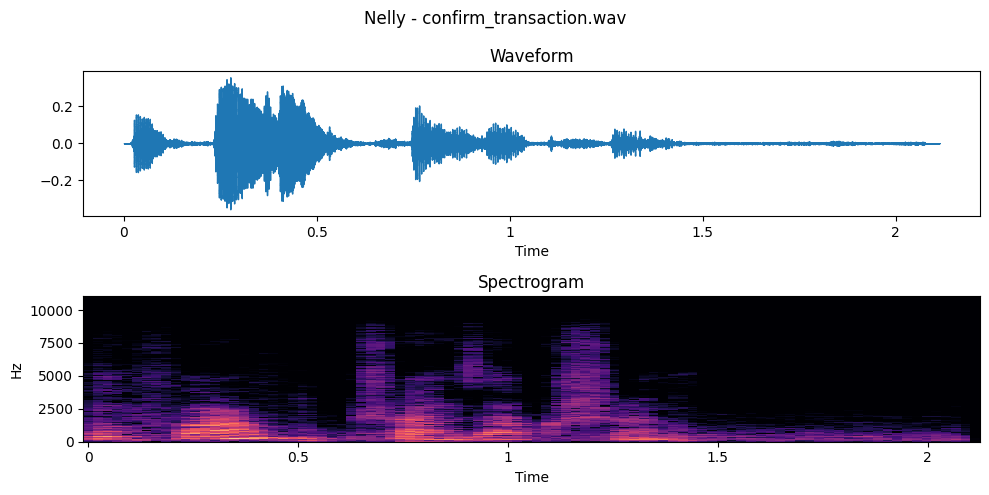

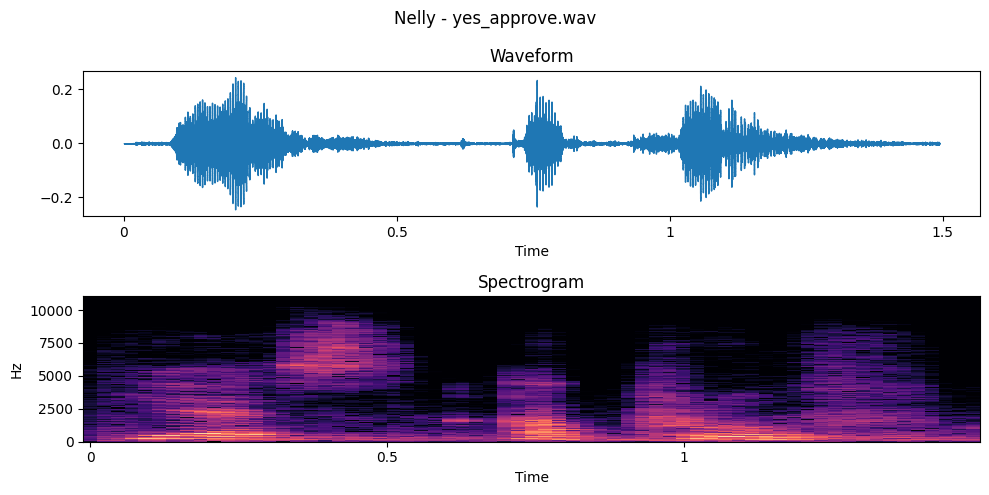

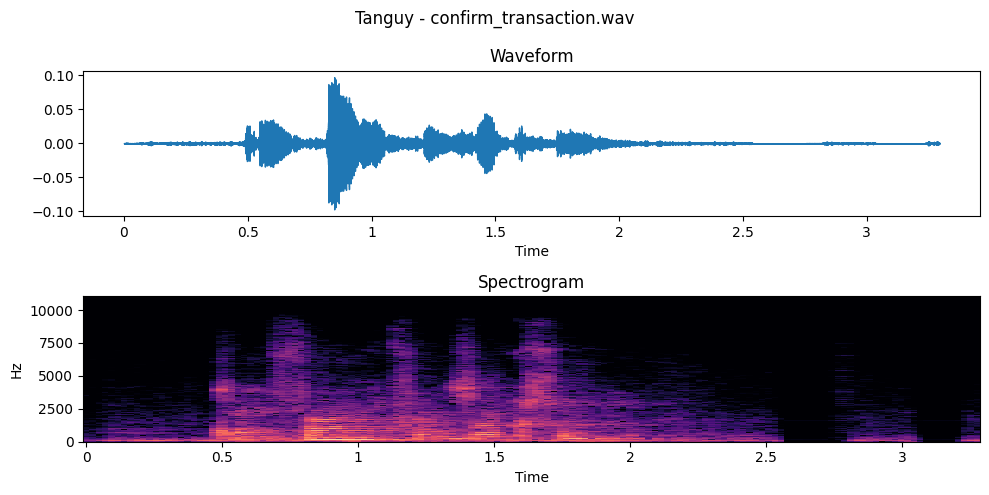

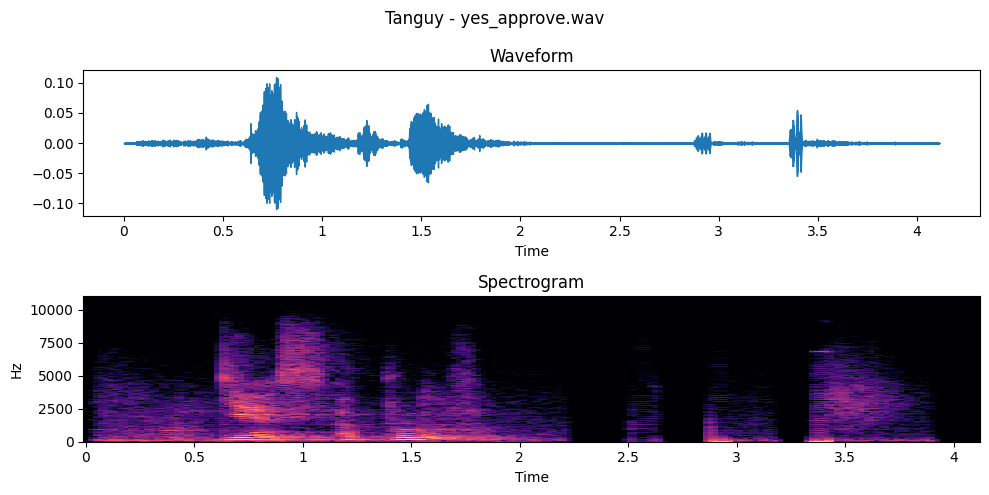

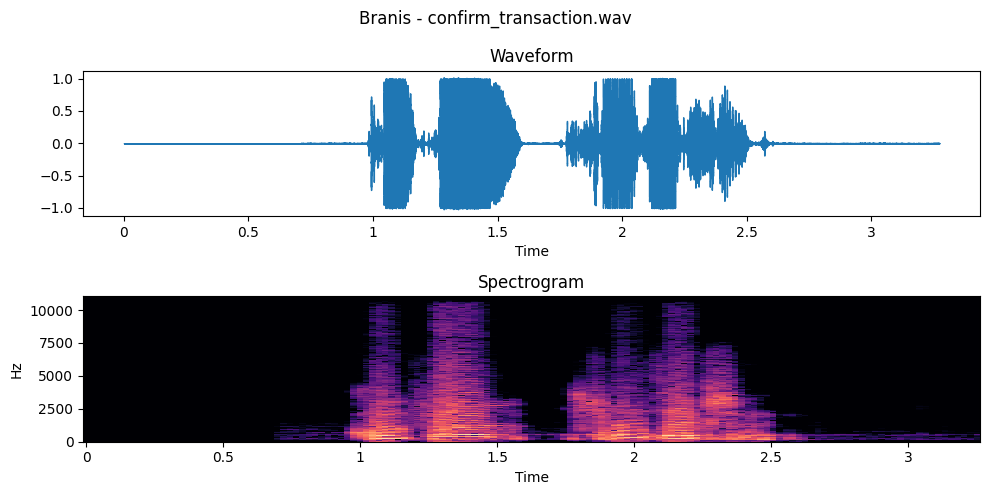

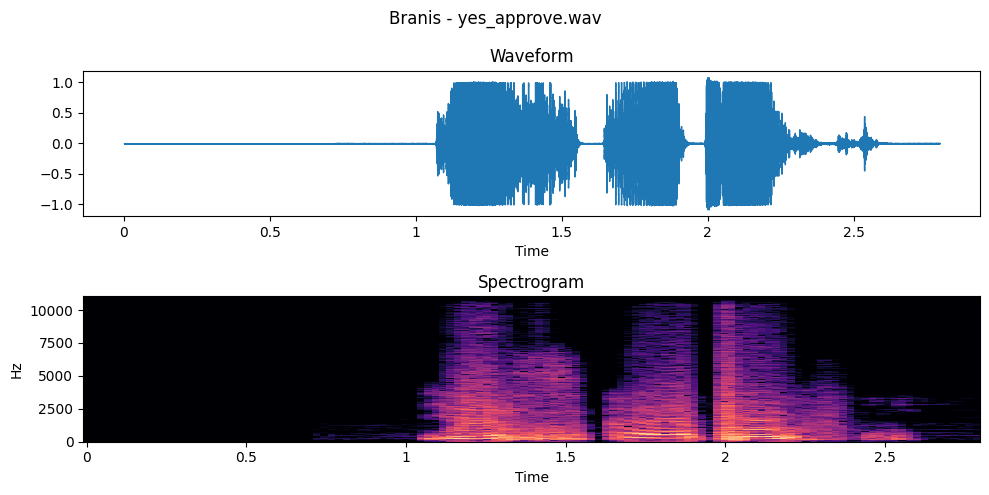

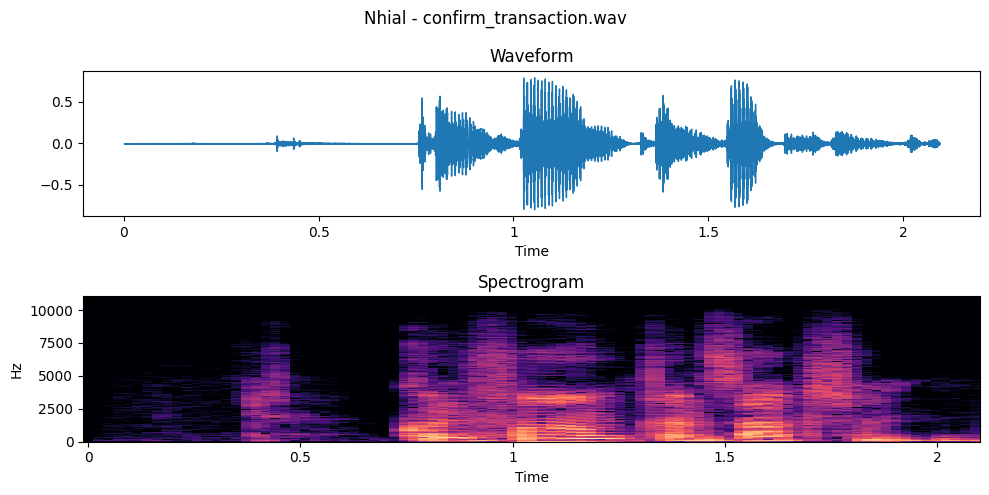

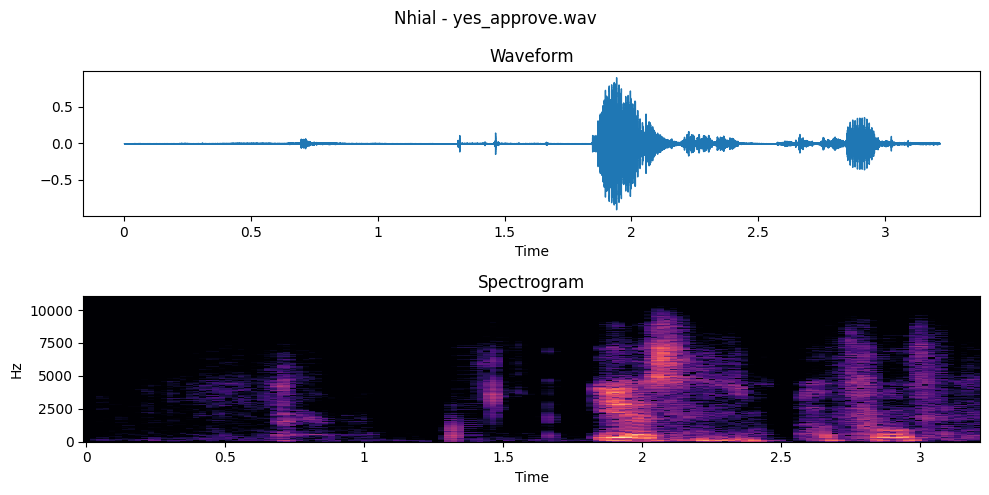

In [11]:
def plot_audio(member, file):
    y, sr = librosa.load(file)
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    fig.suptitle(f"{member} - {file.name}")
    
    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title("Waveform")
    
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax[1])
    ax[1].set_title("Spectrogram")
    
    plt.tight_layout()
    plt.show()

for member in members:
    member_folder = audio_path / member
    for wav_file in member_folder.glob("*.wav"):
        plot_audio(member, wav_file)


Audio Augmentation Functions

### 4. Define augmentation functions: pitch shift and time stretch
We apply two augmentations: pitch shift and time stretch to each audio sample.

In [12]:
def pitch_shift(y, sr):
    return librosa.effects.pitch_shift(y, sr, n_steps=4)

def time_stretch(y):
    return librosa.effects.time_stretch(y, rate=0.8)


Apply augmentations and save


### Apply Audio Augmentations and Save

In this step, we apply two augmentations—**pitch shift** and **time stretch**—to each original audio sample. Augmented audio is saved under the `argumented_audio/<member>/` folder with clear naming conventions for traceability.


In [18]:


# Augmentation functions
def apply_pitch_shift(y, sr):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=4)

def apply_time_stretch(y):
    return librosa.effects.time_stretch(y, rate=1.25)

# Define paths
original_audio_dir = "../audio"
augmented_audio_dir = "../argumented_audio"

# Ensure argumented_audio folders exist
for member in os.listdir(original_audio_dir):
    member_path = os.path.join(augmented_audio_dir, member)
    os.makedirs(member_path, exist_ok=True)

# Process each file
for member in os.listdir(original_audio_dir):
    member_input_path = os.path.join(original_audio_dir, member)
    member_output_path = os.path.join(augmented_audio_dir, member)
    
    for filename in os.listdir(member_input_path):
        if filename.endswith(".wav"):
            file_path = os.path.join(member_input_path, filename)
            
            # Load original audio
            y, sr = librosa.load(file_path, sr=None)
            
            # Apply augmentations
            aug_y1 = apply_pitch_shift(y, sr)
            aug_y2 = apply_time_stretch(y)
            
            # Create filenames
            base_filename = Path(filename).stem
            aug1_filename = f"{base_filename}_pitch.wav"
            aug2_filename = f"{base_filename}_stretch.wav"
            
            # Save augmented files
            sf.write(os.path.join(member_output_path, aug1_filename), aug_y1, sr)
            sf.write(os.path.join(member_output_path, aug2_filename), aug_y2, sr)

print(" Augmented audio saved to 'argumented_audio/<member>/'")


 Augmented audio saved to 'argumented_audio/<member>/'


Extract features (MFCC, roll-off, energy)

### 6. Extract features from both original and augmented audio
We extract MFCCs (mean), spectral roll-off, and energy, then save into a CSV file.


In [16]:
def extract_features(file_path):
    y, sr = librosa.load(file_path)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfccs_mean = mfccs.mean()
    
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0].mean()
    energy = np.sum(y ** 2) / len(y)
    
    return mfccs_mean, rolloff, energy


Collect features for all audio (original + augmented)

###  Loop through all audio and save extracted features
We go through both `audio/` and `argumented_audio/` folders for all members.


In [17]:
feature_rows = []

# Original audio
for member in members:
    folder = audio_path / member
    for wav_file in folder.glob("*.wav"):
        mfcc, roll, en = extract_features(wav_file)
        feature_rows.append({
            "member": member,
            "filename": wav_file.name,
            "mfcc_mean": mfcc,
            "rolloff_mean": roll,
            "energy": en
        })

# Augmented audio
for member in members:
    folder = aug_path / member
    for wav_file in folder.glob("*.wav"):
        mfcc, roll, en = extract_features(wav_file)
        feature_rows.append({
            "member": member,
            "filename": wav_file.name,
            "mfcc_mean": mfcc,
            "rolloff_mean": roll,
            "energy": en
        })

df = pd.DataFrame(feature_rows)
df.to_csv(root / "audio_features.csv", index=False)
df.head()


,member,filename,mfcc_mean,rolloff_mean,energy
0,Nelly,confirm_transaction.wav,-21.499767,1809.608260,0.002321
1,Nelly,yes_approve.wav,-21.973009,2880.148738,0.001186
2,Tanguy,confirm_transaction.wav,-30.003117,2828.507544,0.000055
3,Tanguy,yes_approve.wav,-31.659573,3630.219809,0.000093
4,Branis,confirm_transaction.wav,-19.966297,3245.175885,0.083016
